# 00 — Why average predictions can fail

This is an original, reduced **PyTorch algebraic toy** for the course opening.
For a control value $s\in[0.25,1]$, define

$$
W(q;s)=\frac{(q^2-s)^2}{4}.
$$

Each $s>0$ has two zero-energy reference branches,
$q_+(s)=+\sqrt{s}$ and $q_-(s)=-\sqrt{s}$.  We compare two objectives:

- a supervised squared-error model trained on *balanced* samples from both
  branches, whose conditional target mean is near $q=0$;
- a residual/energy-trained model with an **explicit positive branch
  selection**, $q=\operatorname{softplus}(a)>0$.

This is not PhAST fracture, a solver-in-the-loop experiment, or a
generative model that covers both modes.  It only makes a compact point:
multimodal targets, objective choice, and branch selection matter.

In [1]:
from pathlib import Path
import json
import platform
import time

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F

torch.manual_seed(20260909)
torch.set_num_threads(1)
dtype = torch.float64

def locate_course_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        direct = base / "teaching" / "ukacm_autumn_school_2026"
        if (direct / "assets").is_dir():
            return direct
        if (base / "notebooks").is_dir() and (base / "assets").is_dir():
            return base
    raise FileNotFoundError("Could not find the UKACM course root.")

COURSE_ROOT = locate_course_root()
ASSETS = COURSE_ROOT / "assets" / "teaser"
ASSETS.mkdir(parents=True, exist_ok=True)
print({
    "scope": "original reduced algebraic energy toy; not PhAST fracture or a solver-in-loop result",
    "torch": torch.__version__,
    "device": "cpu",
    "dtype": str(dtype),
    "threads": torch.get_num_threads(),
})

{'scope': 'original reduced algebraic energy toy; not PhAST fracture or a solver-in-loop result', 'torch': '2.8.0', 'device': 'cpu', 'dtype': 'torch.float64', 'threads': 1}


## Balanced supervision versus an energy objective

The training inputs are repeated so that every $s$ has one positive and
one negative target.  Under squared error, the best single deterministic
prediction is their conditional mean, $0$.  That point is between the
two reference branches and has nonzero residual $q^2-s=-s$.

In [2]:
s_unique = torch.linspace(0.25, 1.00, 96, dtype=dtype).unsqueeze(1)
branch_positive = torch.sqrt(s_unique)
branch_negative = -branch_positive
s_supervised = s_unique.repeat_interleave(2, dim=0)
q_supervised_target = torch.stack(
    (branch_positive.squeeze(1), branch_negative.squeeze(1)), dim=1
).reshape(-1, 1)
s_heldout = torch.linspace(0.255, 0.995, 73, dtype=dtype).unsqueeze(1)

def residual(q, s):
    return q.square() - s

def energy(q, s):
    return residual(q, s).square() / 4.0

class TinyScalarMLP(nn.Module):
    def __init__(self, positive_branch=False):
        super().__init__()
        self.hidden = nn.Sequential(
            nn.Linear(1, 16),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
        )
        self.positive_branch = positive_branch

    def forward(self, s):
        raw = self.hidden(s)
        return F.softplus(raw) + 1.0e-8 if self.positive_branch else raw

print({
    "unique_s_train": int(s_unique.shape[0]),
    "balanced_supervised_pairs": int(s_supervised.shape[0]),
    "heldout_s": int(s_heldout.shape[0]),
    "reference_branches_per_s": 2,
})

{'unique_s_train': 96, 'balanced_supervised_pairs': 192, 'heldout_s': 73, 'reference_branches_per_s': 2}


In [3]:
torch.manual_seed(20260909)
supervised_model = TinyScalarMLP().to(dtype=dtype)
supervised_optimiser = torch.optim.Adam(supervised_model.parameters(), lr=2.0e-2)
supervised_start = time.perf_counter()
for _ in range(800):
    supervised_optimiser.zero_grad(set_to_none=True)
    supervised_loss = torch.mean(
        (supervised_model(s_supervised) - q_supervised_target).square()
    )
    supervised_loss.backward()
    supervised_optimiser.step()
supervised_seconds = time.perf_counter() - supervised_start

torch.manual_seed(20260910)
positive_model = TinyScalarMLP(positive_branch=True).to(dtype=dtype)
positive_optimiser = torch.optim.Adam(positive_model.parameters(), lr=2.0e-2)
positive_start = time.perf_counter()
for _ in range(1000):
    positive_optimiser.zero_grad(set_to_none=True)
    positive_loss = energy(positive_model(s_unique), s_unique).mean()
    positive_loss.backward()
    positive_optimiser.step()
positive_seconds = time.perf_counter() - positive_start

print({
    "supervised_mse_on_balanced_targets": float(supervised_loss.detach()),
    "energy_loss_positive_branch": float(positive_loss.detach()),
    "supervised_training_seconds": round(supervised_seconds, 4),
    "positive_branch_training_seconds": round(positive_seconds, 4),
})

{'supervised_mse_on_balanced_targets': 0.6250000049495941, 'energy_loss_positive_branch': 1.6824936103105914e-06, 'supervised_training_seconds': 0.2126, 'positive_branch_training_seconds': 0.2239}


## A stationary point can still be wrong

The energy derivative is

$$
\frac{\partial W}{\partial q}=q(q^2-s).
$$

Thus $q=0$ has zero energy gradient even though its residual is $-s$ and
its energy is positive when $s>0$.  The next cell evaluates that fact
directly.  The successful energy model above avoids a zero-output start
by selecting the positive branch with a softplus output; it does not
discover both branches.

In [4]:
s_stationary = torch.tensor(0.64, dtype=dtype)
q_stationary = torch.tensor(0.0, dtype=dtype, requires_grad=True)
W_stationary = energy(q_stationary, s_stationary)
(grad_stationary,) = torch.autograd.grad(W_stationary, q_stationary)
r_stationary = residual(q_stationary.detach(), s_stationary)
print({
    "s": float(s_stationary),
    "W_at_q0": float(W_stationary.detach()),
    "residual_at_q0": float(r_stationary),
    "dW_dq_at_q0": float(grad_stationary),
})
assert abs(float(grad_stationary)) < 1.0e-15
assert abs(float(r_stationary)) > 0.1

{'s': 0.64, 'W_at_q0': 0.1024, 'residual_at_q0': -0.64, 'dW_dq_at_q0': -0.0}


In [5]:
with torch.no_grad():
    q_supervised = supervised_model(s_heldout)
    q_positive = positive_model(s_heldout)
    r_supervised = residual(q_supervised, s_heldout)
    r_positive = residual(q_positive, s_heldout)
    W_supervised = energy(q_supervised, s_heldout)
    W_positive = energy(q_positive, s_heldout)
    metrics = {
        "heldout_count": int(s_heldout.shape[0]),
        "supervised_max_abs_prediction": float(q_supervised.abs().max()),
        "supervised_mean_abs_residual": float(r_supervised.abs().mean()),
        "supervised_mean_energy": float(W_supervised.mean()),
        "positive_min_prediction": float(q_positive.min()),
        "positive_mean_abs_residual": float(r_positive.abs().mean()),
        "positive_max_abs_residual": float(r_positive.abs().max()),
        "positive_mean_energy": float(W_positive.mean()),
        "positive_branch_rmse": float(
            torch.sqrt(torch.mean((q_positive - torch.sqrt(s_heldout)).square()))
        ),
    }

assert metrics["supervised_max_abs_prediction"] < 0.03
assert metrics["supervised_mean_abs_residual"] > 0.50
assert metrics["positive_min_prediction"] > 0.0
assert metrics["positive_mean_abs_residual"] < 0.02
assert metrics["positive_mean_energy"] < metrics["supervised_mean_energy"]
print(metrics)
(ASSETS / "teaser_metrics.json").write_text(
    json.dumps(metrics, indent=2), encoding="utf-8"
)

{'heldout_count': 73, 'supervised_max_abs_prediction': 0.0001623609215912064, 'supervised_mean_abs_residual': 0.6249999952779399, 'supervised_mean_energy': 0.10938147994308955, 'positive_min_prediction': 0.5136183526070731, 'positive_mean_abs_residual': 0.002002033038503439, 'positive_max_abs_residual': 0.00880381213480369, 'positive_mean_energy': 1.5331257738901223e-06, 'positive_branch_rmse': 0.001987931297689105}


439

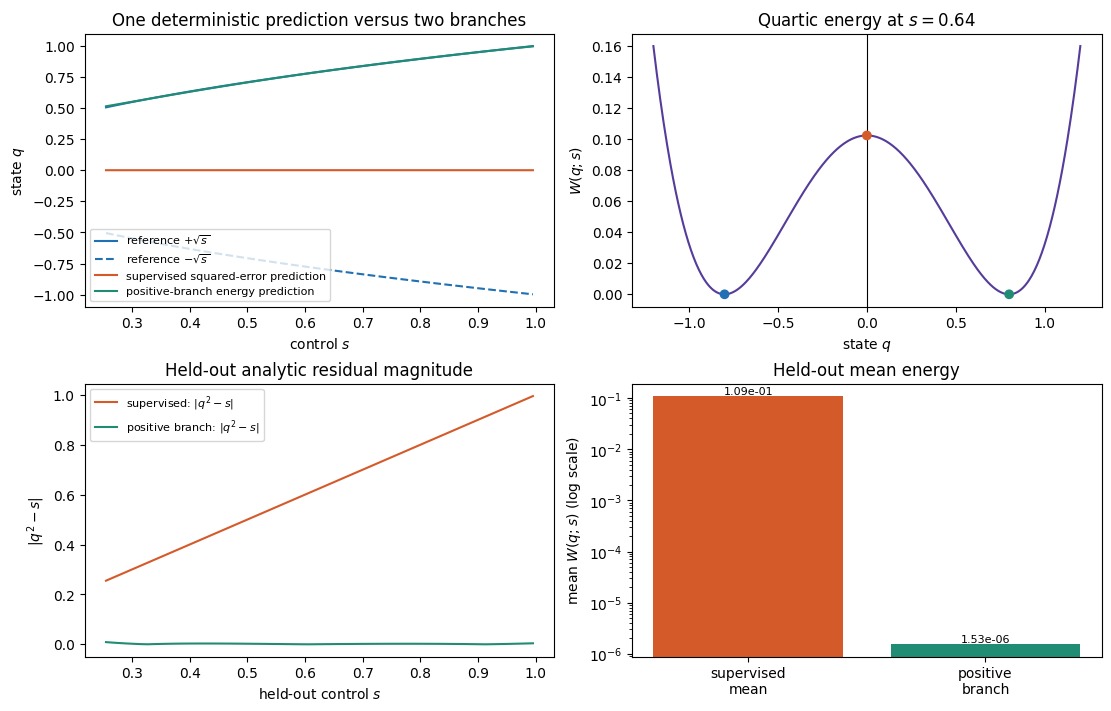

{'figure': 'assets/teaser/why_average_predictions_can_fail.png', 'metrics': {'heldout_count': 73, 'supervised_max_abs_prediction': 0.0001623609215912064, 'supervised_mean_abs_residual': 0.6249999952779399, 'supervised_mean_energy': 0.10938147994308955, 'positive_min_prediction': 0.5136183526070731, 'positive_mean_abs_residual': 0.002002033038503439, 'positive_max_abs_residual': 0.00880381213480369, 'positive_mean_energy': 1.5331257738901223e-06, 'positive_branch_rmse': 0.001987931297689105}}


In [6]:
s_plot = s_heldout.squeeze(1).cpu().numpy()
q_sup_plot = q_supervised.squeeze(1).cpu().numpy()
q_pos_plot = q_positive.squeeze(1).cpu().numpy()
r_sup_plot = r_supervised.abs().squeeze(1).cpu().numpy()
r_pos_plot = r_positive.abs().squeeze(1).cpu().numpy()
s_energy = torch.tensor(0.64, dtype=dtype)
q_axis = torch.linspace(-1.2, 1.2, 500, dtype=dtype)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
axes[0, 0].plot(s_plot, torch.sqrt(s_heldout).squeeze(1).cpu().numpy(),
                color="#2070b4", label=r"reference $+\sqrt{s}$")
axes[0, 0].plot(s_plot, -torch.sqrt(s_heldout).squeeze(1).cpu().numpy(),
                color="#2070b4", linestyle="--", label=r"reference $-\sqrt{s}$")
axes[0, 0].plot(s_plot, q_sup_plot, color="#d45a2a",
                label="supervised squared-error prediction")
axes[0, 0].plot(s_plot, q_pos_plot, color="#218c74",
                label="positive-branch energy prediction")
axes[0, 0].set(title="One deterministic prediction versus two branches",
               xlabel=r"control $s$", ylabel=r"state $q$")
axes[0, 0].legend(fontsize=8, loc="best")

axes[0, 1].plot(q_axis.cpu().numpy(), energy(q_axis, s_energy).cpu().numpy(),
                color="#553c9a")
axes[0, 1].scatter([0.0, float(torch.sqrt(s_energy)), -float(torch.sqrt(s_energy))],
                   [float(energy(torch.tensor(0.0, dtype=dtype), s_energy)),
                    0.0, 0.0],
                   color=["#d45a2a", "#218c74", "#2070b4"], zorder=3)
axes[0, 1].axvline(0.0, color="black", linewidth=0.8)
axes[0, 1].set(title=r"Quartic energy at $s=0.64$",
               xlabel=r"state $q$", ylabel=r"$W(q;s)$")

axes[1, 0].plot(s_plot, r_sup_plot, color="#d45a2a",
                label="supervised: $|q^2-s|$")
axes[1, 0].plot(s_plot, r_pos_plot, color="#218c74",
                label="positive branch: $|q^2-s|$")
axes[1, 0].set(title="Held-out analytic residual magnitude",
               xlabel=r"held-out control $s$", ylabel=r"$|q^2-s|$")
axes[1, 0].legend(fontsize=8)

names = ["supervised\nmean", "positive\nbranch"]
axes[1, 1].bar(names, [metrics["supervised_mean_energy"], metrics["positive_mean_energy"]],
               color=["#d45a2a", "#218c74"])
axes[1, 1].set_yscale("log")
axes[1, 1].set(title="Held-out mean energy",
               ylabel=r"mean $W(q;s)$ (log scale)")
for index, value in enumerate(
    [metrics["supervised_mean_energy"], metrics["positive_mean_energy"]]
):
    axes[1, 1].text(index, value, f"{value:.2e}", ha="center", va="bottom", fontsize=8)

figure_path = ASSETS / "why_average_predictions_can_fail.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print({"figure": str(figure_path.relative_to(COURSE_ROOT)), "metrics": metrics})

## Interpret the teaser

The supervised model is close to the balanced conditional mean, which is
near $q=0$ and is not one of the two zero-energy branches for $s>0$.
The energy-trained model is useful here because the positive softplus
output explicitly commits to one branch and starts away from the
stationary $q=0$ point.  It represents **one** positive branch only.

This example does not show generative multimodal coverage, PhAST
phase-field fracture, a residual from an FE calculation, solver-in-loop
differentiation, or a performance gain.  It also shows a limitation:
a nonzero residual can coexist with a zero quartic-energy gradient at
$q=0$, so a physics loss is not automatically an optimisation success.